In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [19]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")
Main.include("renormalon.jl")

Range Choice

In [3]:
χ_lower = 115
χ_upper = 165

Read Data

In [4]:
#-------------------------------------------------------------------
dataset_names = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

dataset_qua = ["OPAL","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

Chi-Square calculation

In [5]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

Define Objective

In [22]:
import sys
def objective(params, df, Q_list, dataset_names, if_renormalon):

    #----------
    XLL = "NNLL"
    XLO = 1 # 1:LO 2:NLO
    #----------

    N = 5
    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist_mid=np.array(df[name]["CHI"])
        binsize=abs(xlist_mid[1]-xlist_mid[0]) # Evenly sized bins assumed
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/4

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        l = len(xlist_mid)
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters, Ω1=Ω1)
                DELTA =  DELTA_func(ylist,PRED)
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, Ω1=Ω1)              
                DELTA =  DELTA_func(ylist,PRED)               
        else:
            parameters = params_noαs
            if len(parameters) > 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters)                
                DELTA =  DELTA_func(ylist,PRED)             
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO)              
                DELTA =  DELTA_func(ylist,PRED)              

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/length

Define minimization related

In [11]:
class ProgressCallback:
    def __init__(self, df, Q_list, dataset_names, if_renormalon):
        self.df = df
        self.Q_list = Q_list
        self.dataset_names = dataset_names
        self.if_renormalon = if_renormalon
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.df, self.Q_list, self.dataset_names, self.if_renormalon)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [23]:
objective([0.118,0.0,0.0,0.0], df_truncated, Q_list, dataset_names, False)

23.311144929408062

In [11]:
if_renormalon = False

Global

In [11]:
bounds = [ #[ 0.11 , 0.126], # αs
           #[-0.0  , 1.0  ], # Ω1
           [-1.0  , 1.0  ], # a1
           [-1.0  , 1.0  ], # a2
           [-1.0  , 1.0  ], # a3         
        ]

n_points = 17
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[-1.0, -1.0, -1.0], [-1.0, -1.0, -0.875], [-1.0, -1.0, -0.75], [-1.0, -1.0, -0.625], [-1.0, -1.0, -0.5], [-1.0, -1.0, -0.375], [-1.0, -1.0, -0.25], [-1.0, -1.0, -0.125], [-1.0, -1.0, 0.0], [-1.0, -1.0, 0.125], [-1.0, -1.0, 0.25], [-1.0, -1.0, 0.375], [-1.0, -1.0, 0.5], [-1.0, -1.0, 0.625], [-1.0, -1.0, 0.75], [-1.0, -1.0, 0.875], [-1.0, -1.0, 1.0], [-1.0, -0.875, -1.0], [-1.0, -0.875, -0.875], [-1.0, -0.875, -0.75], [-1.0, -0.875, -0.625], [-1.0, -0.875, -0.5], [-1.0, -0.875, -0.375], [-1.0, -0.875, -0.25], [-1.0, -0.875, -0.125], [-1.0, -0.875, 0.0], [-1.0, -0.875, 0.125], [-1.0, -0.875, 0.25], [-1.0, -0.875, 0.375], [-1.0, -0.875, 0.5], [-1.0, -0.875, 0.625], [-1.0, -0.875, 0.75], [-1.0, -0.875, 0.875], [-1.0, -0.875, 1.0], [-1.0, -0.75, -1.0], [-1.0, -0.75, -0.875], [-1.0, -0.75, -0.75], [-1.0, -0.75, -0.625], [-1.0, -0.75, -0.5], [-1.0, -0.75, -0.375], [-1.0, -0.75, -0.25], [-1.0, -0.75, -0.125], [-1.0, -0.75, 0.0], [-1.0, -0.75, 0.125], [-1.0, -0.75, 0.25], [-1.0, -0.75, 0.375], 

In [12]:
chi2_list = []
for parameters in tqdm(params):
    parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, df_truncated, Q_list, dataset_names, if_renormalon))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

  0%|          | 1/4913 [00:02<3:31:33,  2.58s/it]


KeyboardInterrupt: 

Local then hopping

In [12]:
initial_params = [0.118,0.0,0.0,0.0] #best_params

bounds = [ [0.11 , 0.13], # αs
           #[-1.0 , 1.0  ], # Ω1
            [-3.0, 3.0  ], # a1
            [-3.0, 3.0  ], # a2
            [-3.0, 3.0  ]  # a3          
        ]

bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(df_truncated, Q_list, dataset_names, if_renormalon)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (df_truncated, Q_list, dataset_names, if_renormalon),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=0,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [ 0.12054726  0.63681601 -0.63681601 -0.63681601], Chi2/dof: 8.912140736274953
Iteration: 2, Params: [ 0.12165082  0.41807015 -0.41807816 -0.41803003], Chi2/dof: 3.9002591074523374
Iteration: 3, Params: [ 0.12390403  0.24700014 -0.24701726 -0.24690876], Chi2/dof: 2.30857992746742
Iteration: 4, Params: [ 0.1244128   0.23482253 -0.23485008 -0.23470075], Chi2/dof: 2.2778657637980406
Iteration: 5, Params: [ 0.12463138  0.20158396 -0.2016124  -0.201456  ], Chi2/dof: 2.2368302672965235
Iteration: 6, Params: [ 0.1245784   0.20736563 -0.20740407 -0.20721264], Chi2/dof: 2.2352323928270486
Iteration: 7, Params: [ 0.12459269  0.20683648 -0.20699611 -0.20637098], Chi2/dof: 2.234711147632556
Iteration: 8, Params: [ 0.12467393  0.20464769 -0.20671146 -0.19927323], Chi2/dof: 2.2284119586185445
Iteration: 9, Params: [ 0.12472958  0.2060569  -0.21279998 -0.18862013], Chi2/dof: 2.215452046283489
Iteration: 10, Params: [ 0.12469761  0.21985392 -0.24090481 -0.16553597], Chi2/dof: 2.1

In [ ]:
Main.eval('rmprocs(workers())')

Plot

In [13]:
xlist = np.pi/180*np.linspace(χ_lower,180, 100, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    if if_renormalon: 
        Ω1 = params_noαs[0]
        parameters = params_noαs[1:]  
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="NNLL", parameters=parameters, Ω1=Ω1)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="NNLL", Ω1=Ω1)            
    else:
        parameters = params_noαs
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="NNLL", parameters=parameters)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="NNLL")      

    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

[ 1.66128422 -0.94056328 -0.11832332]


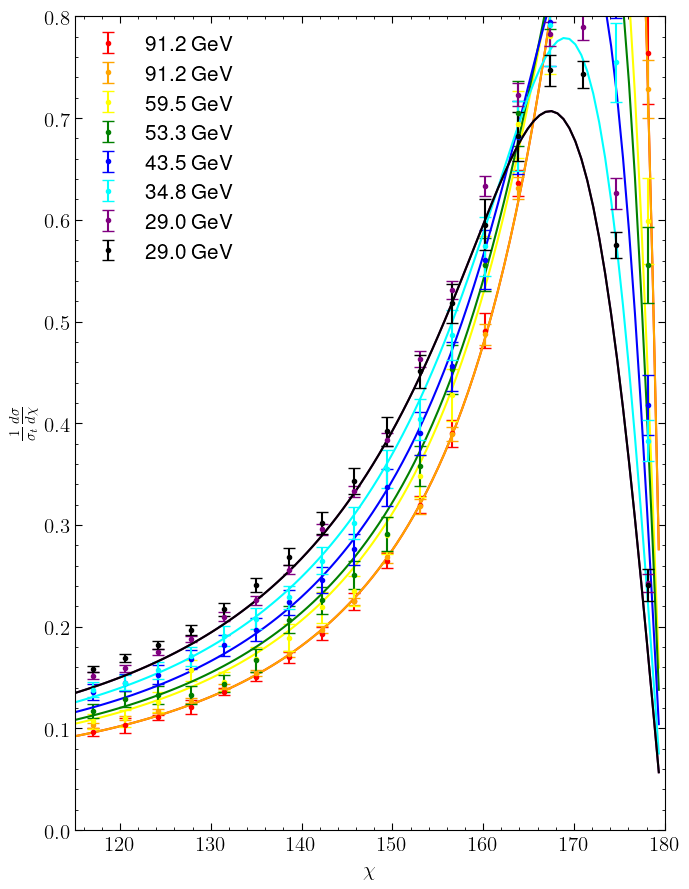

In [14]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0,0.8)
plt.xlim(χ_lower,180)

plt.tight_layout()  
plt.show()

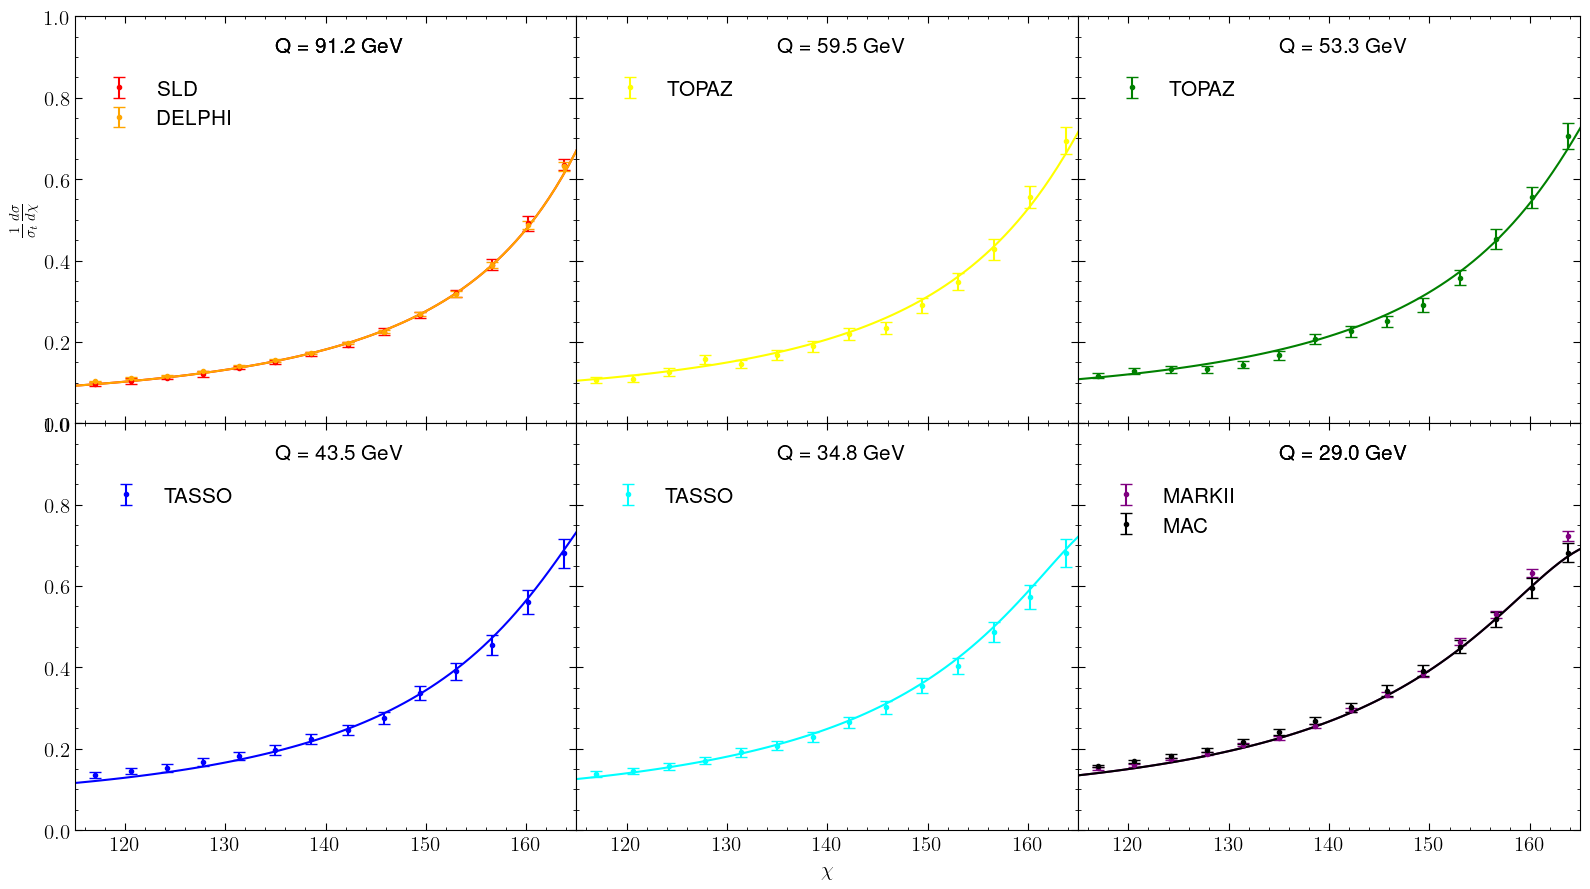

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1)
plt.xlim(χ_lower,χ_upper)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [20]:
average_error={}

for name in dataset_names:
    l = len(χ[name])
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'SLD': 0.0023,
 'DELPHI': 0.0015,
 'TOPAZ_595': 0.0047,
 'TOPAZ_533': 0.0045,
 'TASSO_435': 0.0048,
 'TASSO_348': 0.0047,
 'MARKII': 0.0017,
 'MAC': 0.0036}